# 서울시 대기질 PM10 / PM2.5 농도 예측 모델
서울 전체 측정소 데이터를 기반으로 향후 PM10·PM2.5 농도를 예측합니다.

## 1. 라이브러리 설치 및 임포트

In [1]:
!pip install lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')

라이브러리 로드 완료


In [5]:
# 나눔고딕 설치
!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

# 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 설정 완료')

폰트 설정 완료


## 2. 데이터 로드

In [6]:
# 파일 경로 수정
FILE_PATH = '/content/drive/MyDrive/data.csv'  # 실제 경로로 변경

df = pd.read_csv(FILE_PATH, encoding='cp949')
print(f'데이터 shape: {df.shape}')
print(f'컬럼: {df.columns.tolist()}')
df.head()

데이터 shape: (8760, 12)
컬럼: ['weather_station_id', 'timestamp', 'temp', 'humidity', 'wind_speed', 'wind_dir', 'precip', 'station_name', 'pm10', 'pm25', 'o3', 'no2']


,weather_station_id,timestamp,temp,humidity,wind_speed,wind_dir,precip,station_name,pm10,pm25,o3,no2
0,108.0,2025-01-01 0:00,-1.47,60.53,0.87,257.74,0.0,중구,21.0,12.0,0.0010,0.0306
1,108.0,2025-01-01 1:00,-1.60,63.03,0.70,272.49,0.0,중구,21.0,13.0,0.0011,0.0307
2,108.0,2025-01-01 2:00,-1.75,64.75,0.75,25.65,0.0,중구,19.0,12.0,0.0025,0.0301
3,108.0,2025-01-01 3:00,-2.10,66.50,1.95,28.43,0.0,중구,20.0,12.0,0.0010,0.0307
4,108.0,2025-01-01 4:00,-2.37,67.97,1.96,32.87,0.0,중구,23.0,12.0,0.0012,0.0281


## 3. 탐색적 데이터 분석 (EDA)

In [7]:
# 기본 정보
print('=== 데이터 타입 ===')
print(df.dtypes)
print()
print('=== 결측치 수 ===')
print(df.isnull().sum())
print()
print('=== 기초 통계 ===')
df.describe()

=== 데이터 타입 ===
weather_station_id    float64
timestamp              object
temp                  float64
humidity              float64
wind_speed            float64
wind_dir              float64
precip                float64
station_name           object
pm10                  float64
pm25                  float64
o3                    float64
no2                   float64
dtype: object

=== 결측치 수 ===
weather_station_id    112
timestamp               0
temp                  135
humidity              135
wind_speed            142
wind_dir              142
precip                201
station_name            0
pm10                  251
pm25                  143
o3                    129
no2                   105
dtype: int64

=== 기초 통계 ===


,weather_station_id,temp,humidity,wind_speed,wind_dir,precip,pm10,pm25,o3,no2
count,8648.0,8625.000000,8625.00000,8618.000000,8618.000000,8559.000000,8509.000000,8617.000000,8631.000000,8655.000000
mean,108.0,14.219659,66.09357,2.335116,184.764260,2.345475,29.431308,19.408727,0.034617,0.019396
std,0.0,11.312156,18.23558,1.039610,103.616497,9.450029,19.909230,15.523287,0.020127,0.011866
min,108.0,-12.080000,13.01000,0.130000,0.170000,0.000000,3.000000,1.000000,0.000100,0.003900
25%,108.0,4.530000,52.78000,1.570000,58.747500,0.000000,16.000000,9.000000,0.020750,0.010700
50%,108.0,15.240000,67.00000,2.200000,223.375000,0.000000,25.000000,15.000000,0.032700,0.015800
75%,108.0,23.930000,81.09000,2.950000,272.215000,0.000000,37.000000,25.000000,0.045100,0.024400
max,108.0,37.680000,99.73000,7.340000,359.970000,126.700000,178.000000,130.000000,0.146500,0.081800


In [8]:
# 데이터 기간 확인
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'시작: {df["timestamp"].min()}')
print(f'종료: {df["timestamp"].max()}')
print(f'측정소 수: {df["weather_station_id"].nunique()}')
print(f'총 기간: {(df["timestamp"].max() - df["timestamp"].min()).days}일')

시작: 2025-01-01 00:00:00
종료: 2025-12-31 23:00:00
측정소 수: 1
총 기간: 364일


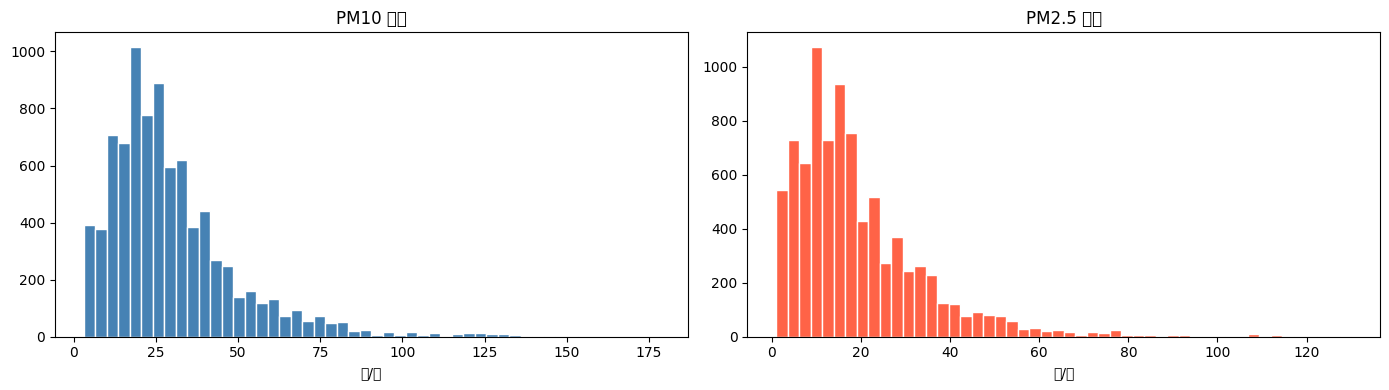

In [9]:
# PM10 / PM2.5 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['pm10'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PM10 분포')
axes[0].set_xlabel('㎍/㎥')

axes[1].hist(df['pm25'].dropna(), bins=50, color='tomato', edgecolor='white')
axes[1].set_title('PM2.5 분포')
axes[1].set_xlabel('㎍/㎥')

plt.tight_layout()
plt.show()

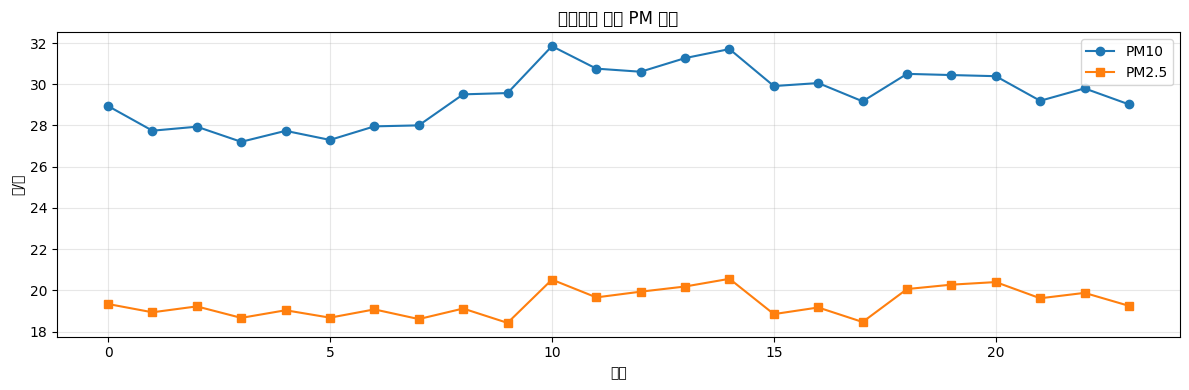

In [10]:
# 시간대별 평균 PM 농도
hourly = df.groupby(df['timestamp'].dt.hour)[['pm10', 'pm25']].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly['pm10'], label='PM10', marker='o')
ax.plot(hourly.index, hourly['pm25'], label='PM2.5', marker='s')
ax.set_title('시간대별 평균 PM 농도')
ax.set_xlabel('시간')
ax.set_ylabel('㎍/㎥')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

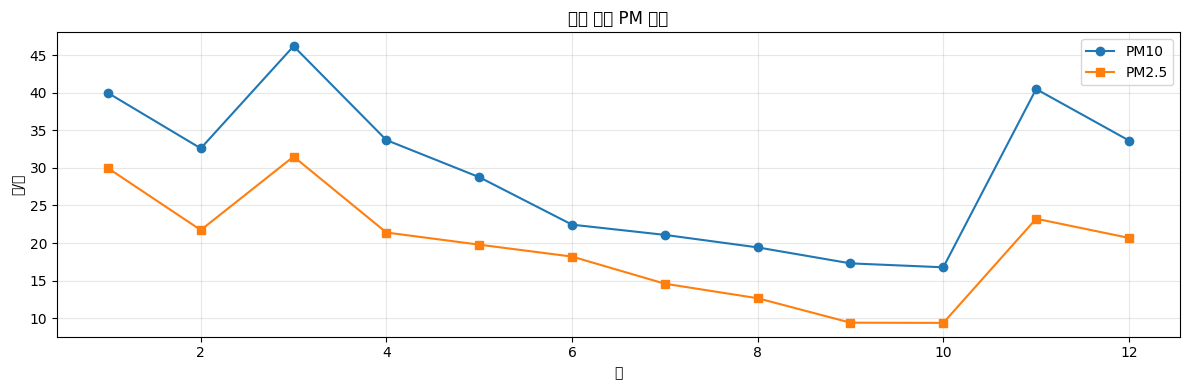

In [11]:
# 월별 평균 PM 농도
monthly = df.groupby(df['timestamp'].dt.month)[['pm10', 'pm25']].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly['pm10'], label='PM10', marker='o')
ax.plot(monthly.index, monthly['pm25'], label='PM2.5', marker='s')
ax.set_title('월별 평균 PM 농도')
ax.set_xlabel('월')
ax.set_ylabel('㎍/㎥')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 전처리

In [12]:
# timestamp 정렬
df = df.sort_values('timestamp').reset_index(drop=True)

# 이상치 → NaN 처리
df.loc[df['pm10'] < 0,   'pm10'] = np.nan
df.loc[df['pm10'] > 600, 'pm10'] = np.nan
df.loc[df['pm25'] < 0,   'pm25'] = np.nan
df.loc[df['pm25'] > 300, 'pm25'] = np.nan
df.loc[df['temp'] < -20, 'temp'] = np.nan
df.loc[df['temp'] > 45,  'temp'] = np.nan

print(f'이상치 처리 후 결측치:')
print(df[['pm10','pm25','temp','humidity','wind_speed']].isnull().sum())

이상치 처리 후 결측치:
pm10          251
pm25          143
temp          135
humidity      135
wind_speed    142
dtype: int64


In [13]:
# 결측치 선형 보간 (최대 3시간 연속 결측까지만)
for col in ['pm10', 'pm25', 'temp', 'humidity', 'wind_speed', 'wind_dir', 'precip']:
    df[col] = df[col].interpolate(method='linear', limit=3)

# 보간 후에도 남은 결측 행 제거
before = len(df)
df = df.dropna(subset=['pm10', 'pm25'])
print(f'제거된 행: {before - len(df)}개')
print(f'최종 데이터: {len(df)}행')

제거된 행: 61개
최종 데이터: 8699행


## 5. 피처 엔지니어링

In [14]:
# 시간 파생변수
df['hour']    = df['timestamp'].dt.hour
df['month']   = df['timestamp'].dt.month
df['weekday'] = df['timestamp'].dt.weekday
df['season']  = df['month'].map({
    12:0, 1:0, 2:0,
     3:1, 4:1, 5:1,
     6:2, 7:2, 8:2,
     9:3,10:3,11:3
})

# lag feature (직전 N시간 농도)
for lag in [1, 2, 3, 6, 12, 24]:
    df[f'pm10_lag{lag}'] = df['pm10'].shift(lag)
    df[f'pm25_lag{lag}'] = df['pm25'].shift(lag)

# rolling 평균
df['pm10_roll3']  = df['pm10'].shift(1).rolling(3).mean()
df['pm25_roll3']  = df['pm25'].shift(1).rolling(3).mean()
df['pm10_roll24'] = df['pm10'].shift(1).rolling(24).mean()
df['pm25_roll24'] = df['pm25'].shift(1).rolling(24).mean()

# lag 생성으로 생긴 NaN 제거
df = df.dropna()
print(f'피처 엔지니어링 완료: {df.shape}')

피처 엔지니어링 완료: (8388, 32)


## 6. Train / Test 분할

In [15]:
# 시간 순서대로 분할 (마지막 30일 = 테스트)
# 주의: 시계열은 랜덤 분할 금지
split_date = df['timestamp'].max() - pd.Timedelta(days=30)

train = df[df['timestamp'] <= split_date]
test  = df[df['timestamp'] >  split_date]

print(f'Train: {train["timestamp"].min()} ~ {train["timestamp"].max()} ({len(train)}행)')
print(f'Test:  {test["timestamp"].min()}  ~ {test["timestamp"].max()}  ({len(test)}행)')

FEATURES = [
    'hour', 'month', 'weekday', 'season',
    'temp', 'humidity', 'wind_speed', 'wind_dir', 'precip',
    'pm10_lag1', 'pm10_lag2', 'pm10_lag3', 'pm10_lag6', 'pm10_lag12', 'pm10_lag24',
    'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag6', 'pm25_lag12', 'pm25_lag24',
    'pm10_roll3', 'pm25_roll3', 'pm10_roll24', 'pm25_roll24'
]

X_train = train[FEATURES]
X_test  = test[FEATURES]
y_train_pm10 = train['pm10']
y_test_pm10  = test['pm10']
y_train_pm25 = train['pm25']
y_test_pm25  = test['pm25']

Train: 2025-01-02 00:00:00 ~ 2025-12-01 03:00:00 (7710행)
Test:  2025-12-01 04:00:00  ~ 2025-12-31 03:00:00  (678행)


## 7. 모델 학습 및 비교

In [16]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM':         LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

results = {}

for name, model in models.items():
    # PM10
    model.fit(X_train, y_train_pm10)
    pred_pm10 = model.predict(X_test)
    rmse_pm10 = np.sqrt(mean_squared_error(y_test_pm10, pred_pm10))
    mae_pm10  = mean_absolute_error(y_test_pm10, pred_pm10)

    # PM2.5 (같은 모델 구조로 별도 학습)
    model.fit(X_train, y_train_pm25)
    pred_pm25 = model.predict(X_test)
    rmse_pm25 = np.sqrt(mean_squared_error(y_test_pm25, pred_pm25))
    mae_pm25  = mean_absolute_error(y_test_pm25, pred_pm25)

    results[name] = {
        'PM10_RMSE': round(rmse_pm10, 2), 'PM10_MAE': round(mae_pm10, 2),
        'PM25_RMSE': round(rmse_pm25, 2), 'PM25_MAE': round(mae_pm25, 2),
    }
    print(f'{name}: PM10 RMSE={rmse_pm10:.2f} MAE={mae_pm10:.2f} | PM2.5 RMSE={rmse_pm25:.2f} MAE={mae_pm25:.2f}')

results_df = pd.DataFrame(results).T
results_df

LinearRegression: PM10 RMSE=5.58 MAE=3.82 | PM2.5 RMSE=4.20 MAE=2.85
RandomForest: PM10 RMSE=5.60 MAE=3.75 | PM2.5 RMSE=4.48 MAE=3.01
XGBoost: PM10 RMSE=5.91 MAE=4.10 | PM2.5 RMSE=4.41 MAE=2.92
LightGBM: PM10 RMSE=5.24 MAE=3.47 | PM2.5 RMSE=3.83 MAE=2.61


,PM10_RMSE,PM10_MAE,PM25_RMSE,PM25_MAE
LinearRegression,5.58,3.82,4.20,2.85
RandomForest,5.60,3.75,4.48,3.01
XGBoost,5.91,4.10,4.41,2.92
LightGBM,5.24,3.47,3.83,2.61


## 8. 예측 결과 시각화

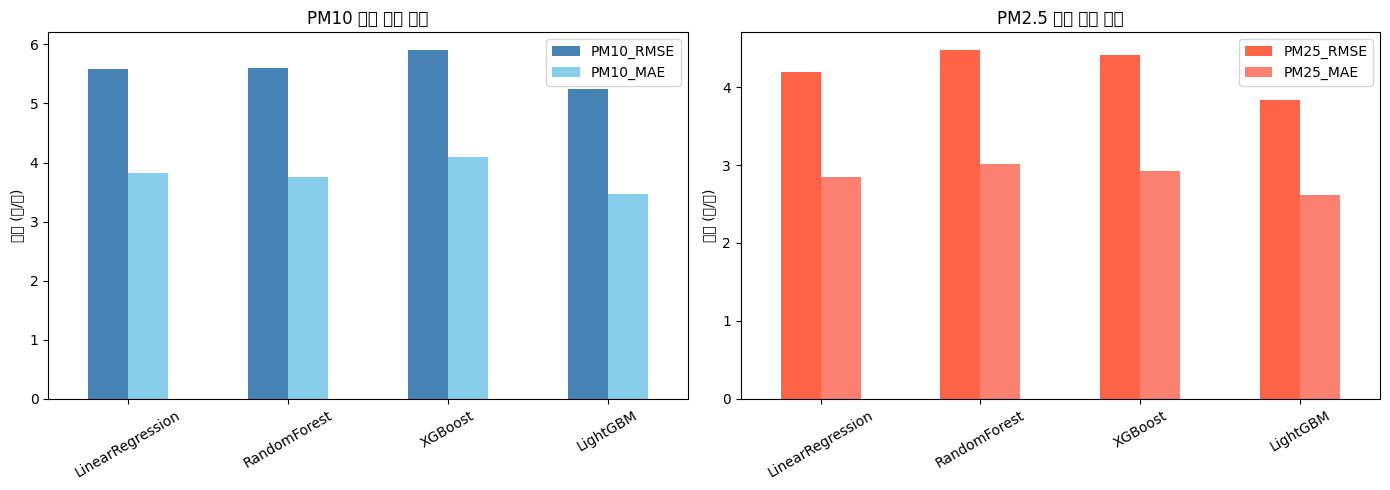

In [17]:
# 모델 비교 막대 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['PM10_RMSE', 'PM10_MAE']].plot(kind='bar', ax=axes[0], color=['steelblue','skyblue'])
axes[0].set_title('PM10 모델 성능 비교')
axes[0].set_ylabel('오차 (㎍/㎥)')
axes[0].tick_params(axis='x', rotation=30)

results_df[['PM25_RMSE', 'PM25_MAE']].plot(kind='bar', ax=axes[1], color=['tomato','salmon'])
axes[1].set_title('PM2.5 모델 성능 비교')
axes[1].set_ylabel('오차 (㎍/㎥)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

PM10 최고 성능 모델: LightGBM


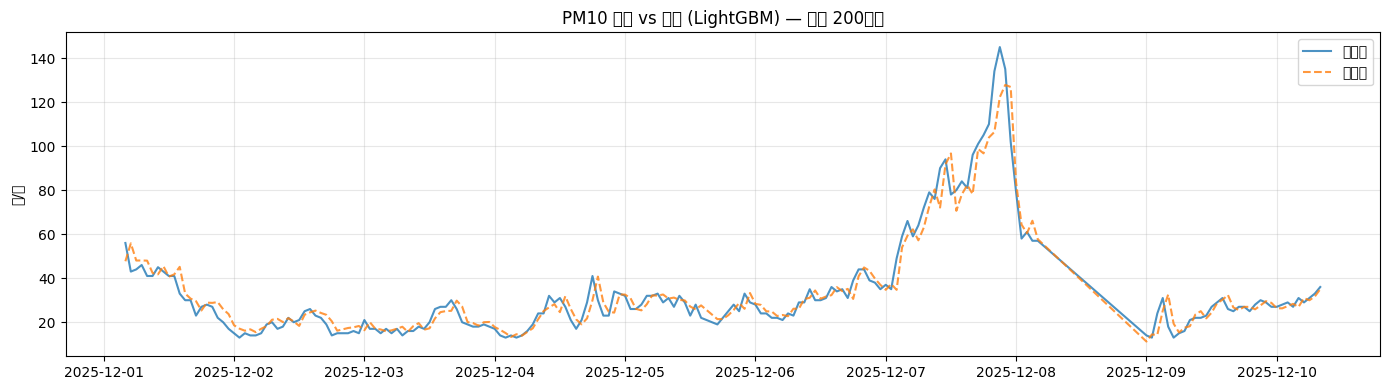

In [18]:
# 최고 성능 모델의 실제 vs 예측 시각화 (PM10)
# 아래 best_model을 결과 보고 직접 교체하세요
best_model_name = results_df['PM10_RMSE'].idxmin()
print(f'PM10 최고 성능 모델: {best_model_name}')

best_model = models[best_model_name]
best_model.fit(X_train, y_train_pm10)
pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test['timestamp'].values[:200], y_test_pm10.values[:200], label='실제값', alpha=0.8)
ax.plot(test['timestamp'].values[:200], pred[:200], label='예측값', alpha=0.8, linestyle='--')
ax.set_title(f'PM10 실제 vs 예측 ({best_model_name}) — 처음 200시간')
ax.set_ylabel('㎍/㎥')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 피처 중요도

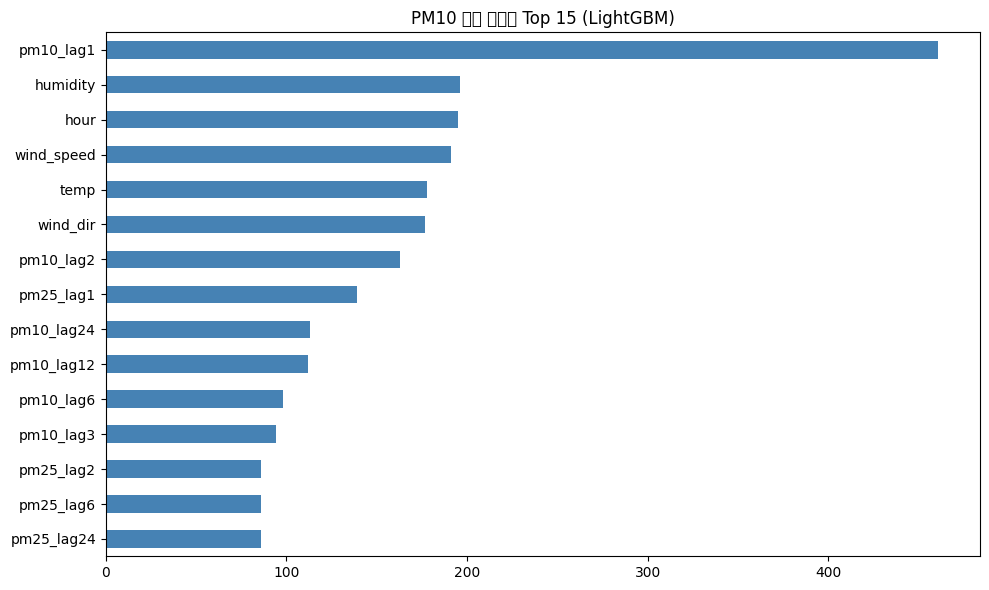

In [19]:
# 트리 기반 모델의 피처 중요도 (LightGBM 기준)
lgbm_pm10 = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgbm_pm10.fit(X_train, y_train_pm10)

importance = pd.Series(lgbm_pm10.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('PM10 피처 중요도 Top 15 (LightGBM)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. 최종 모델 저장

In [20]:
# PM10 모델
final_pm10 = LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
final_pm10.fit(X_train, y_train_pm10)
joblib.dump(final_pm10, 'model_pm10.pkl')

# PM2.5 모델
final_pm25 = LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
final_pm25.fit(X_train, y_train_pm25)
joblib.dump(final_pm25, 'model_pm25.pkl')

# 피처 목록도 저장 (추론 시 동일한 피처 순서 보장)
joblib.dump(FEATURES, 'features.pkl')

print('모델 저장 완료: model_pm10.pkl / model_pm25.pkl / features.pkl')

모델 저장 완료: model_pm10.pkl / model_pm25.pkl / features.pkl


## 11. 추론 함수 (백엔드 연동용)

In [21]:
def predict_pm(input_df: pd.DataFrame) -> dict:
    """
    input_df: 최소 24시간치 과거 데이터가 포함된 DataFrame
              (timestamp, temp, humidity, wind_speed, wind_dir, precip, pm10, pm25 컬럼 필요)
    return: {'pm10': [...], 'pm25': [...]} — 향후 24시간 예측값 리스트
    """
    model_pm10 = joblib.load('model_pm10.pkl')
    model_pm25 = joblib.load('model_pm25.pkl')
    features   = joblib.load('features.pkl')

    df_input = input_df.copy()
    df_input['timestamp'] = pd.to_datetime(df_input['timestamp'])
    df_input = df_input.sort_values('timestamp').reset_index(drop=True)

    predictions_pm10 = []
    predictions_pm25 = []

    for step in range(24):
        last = df_input.iloc[-1:].copy()
        next_time = last['timestamp'].values[0] + pd.Timedelta(hours=1)

        row = {
            'timestamp':  next_time,
            'hour':       pd.Timestamp(next_time).hour,
            'month':      pd.Timestamp(next_time).month,
            'weekday':    pd.Timestamp(next_time).weekday(),
            'temp':       last['temp'].values[0],
            'humidity':   last['humidity'].values[0],
            'wind_speed': last['wind_speed'].values[0],
            'wind_dir':   last['wind_dir'].values[0],
            'precip':     last['precip'].values[0],
        }
        row['season'] = {12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}[row['month']]

        for lag in [1, 2, 3, 6, 12, 24]:
            row[f'pm10_lag{lag}'] = df_input['pm10'].iloc[-lag] if len(df_input) >= lag else np.nan
            row[f'pm25_lag{lag}'] = df_input['pm25'].iloc[-lag] if len(df_input) >= lag else np.nan

        row['pm10_roll3']  = df_input['pm10'].iloc[-3:].mean()
        row['pm25_roll3']  = df_input['pm25'].iloc[-3:].mean()
        row['pm10_roll24'] = df_input['pm10'].iloc[-24:].mean()
        row['pm25_roll24'] = df_input['pm25'].iloc[-24:].mean()

        X_new = pd.DataFrame([row])[features]
        pred_pm10 = round(float(model_pm10.predict(X_new)[0]), 1)
        pred_pm25 = round(float(model_pm25.predict(X_new)[0]), 1)

        predictions_pm10.append(pred_pm10)
        predictions_pm25.append(pred_pm25)

        # 예측값을 다음 스텝의 입력으로 사용
        new_row = pd.DataFrame([{
            'timestamp':  next_time,
            'pm10':       pred_pm10,
            'pm25':       pred_pm25,
            'temp':       row['temp'],
            'humidity':   row['humidity'],
            'wind_speed': row['wind_speed'],
            'wind_dir':   row['wind_dir'],
            'precip':     row['precip'],
        }])
        df_input = pd.concat([df_input, new_row], ignore_index=True)

    return {'pm10': predictions_pm10, 'pm25': predictions_pm25}


# 테스트 실행
sample_input = df.tail(24)[['timestamp','temp','humidity','wind_speed','wind_dir','precip','pm10','pm25']]
result = predict_pm(sample_input)
print('향후 24시간 PM10 예측:', result['pm10'])
print('향후 24시간 PM2.5 예측:', result['pm25'])

향후 24시간 PM10 예측: [17.1, 17.1, 18.9, 19.5, 20.6, 21.1, 23.7, 19.9, 17.4, 20.9, 20.6, 19.5, 19.7, 20.8, 22.7, 22.6, 22.8, 22.8, 23.2, 23.0, 22.1, 20.2, 18.0, 18.1]
향후 24시간 PM2.5 예측: [6.5, 6.0, 6.0, 6.0, 5.9, 5.6, 7.2, 4.7, 5.1, 7.5, 8.5, 7.6, 8.4, 8.7, 9.7, 9.7, 9.8, 9.7, 9.9, 9.9, 8.5, 8.3, 8.1, 7.9]
